In [1]:
# This line imports polars so the AISC section data can be loaded and filtered.
#%pip install polars pyarrow  
#uncomment this line if polars or pyarrow are not installed
import polars as pl
#print(pl.__version__)

# This line imports matplotlib so we can plot our results at the end.
import matplotlib.pyplot as plt

# This line imports seaborn to make the plot look clean and professional.
import seaborn as sns

# This line loads the AISC section property CSV file into Python.
# infer_schema_length=10000 tells polars to scan more rows before deciding each column's data type,
# which prevents it from incorrectly guessing integer for columns that contain decimals further down.
aisc_data = pl.read_csv('CSV.csv', infer_schema_length=10000)

# This line displays the column names and data types to confirm the file loaded correctly.
aisc_data.glimpse()

# This line prints summary statistics for each column in the dataset.
print(aisc_data.describe())

# This line prints the first five rows of the dataset.
print(aisc_data.head())

Rows: 2299
Columns: 166
$ Type                              <str> 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W'
$ EDI_Std_Nomenclature              <str> 'W44X408', 'W44X368', 'W44X335', 'W44X290', 'W44X262', 'W44X230', 'W40X655', 'W40X593', 'W40X503', 'W40X431'
$ AISC_Manual_Label                 <str> 'W44X408', 'W44X368', 'W44X335', 'W44X290', 'W44X262', 'W44X230', 'W40X655', 'W40X593', 'W40X503', 'W40X431'
$ T_F                               <str> 'T', 'F', 'F', 'F', 'F', 'F', 'T', 'T', 'T', 'T'
$ W                                 <f64> 408.0, 368.0, 335.0, 290.0, 262.0, 230.0, 655.0, 593.0, 503.0, 431.0
$ A                                 <f64> 120.0, 108.0, 98.5, 85.4, 77.2, 67.8, 193.0, 174.0, 148.0, 127.0
$ d                                 <str> '44.8', '44.4', '44', '43.6', '43.3', '42.9', '43.6', '43', '42.1', '41.3'
$ ddet                              <str> '44  3/4 ', '44  3/8 ', '44', '43  5/8 ', '43  1/4 ', '42  7/8 ', '43  5/8 ', '43', '42', '41  1/4 '
$ Ht          

In [2]:
# This line filters the dataset to only keep rows where the Type column equals 'W'.
# In polars, filter() with pl.col() replaces the pandas bracket syntax.
w_shapes = aisc_data.filter(pl.col('Type') == 'W')

# Polars DataFrames have no index so reset_index() is not needed here like it would be in pandas.

# This line prints how many W-shapes are in the database so we can confirm the filter worked.
print(f'Total W-shapes available: {len(w_shapes)}')

Total W-shapes available: 289


In [3]:
# This line defines a function that calculates the shear lag factor U per AISC Table D3.1 Case 2.
def calculate_U(x_bar, L):
    # This line applies the shear lag formula where x_bar is the centroid distance and L is the connection length.
    U = 1 - (x_bar / L)
    return U

In [4]:
# This line defines a function that calculates tensile rupture strength given a shape name and connection length.
def tensile_rupture(shape_name, L):
    # This line looks up the row in the W-shapes dataframe that matches the shape name entered.
    # In polars, filter() with pl.col() replaces the pandas boolean bracket syntax.
    row = w_shapes.filter(pl.col('AISC_Manual_Label') == shape_name)

    # This line extracts the gross area Ag from the matched row.
    # In polars, [0] on a column Series replaces the pandas .values[0] syntax.
    Ag = float(row['A'][0])

    # This line extracts the flange width bf from the matched row and converts it to a float for math.
    bf = float(row['bf'][0])

    # This line calculates x_bar as bf divided by 4, which is the centroid distance for a W-shape connected at the flanges.
    x_bar = bf / 4

    # This line sets Fu to 65 ksi, the ultimate tensile stress for all standard ASTM A992 W-shapes.
    Fu = 65

    # This line sets the net area An equal to Ag because a welded connection has no bolt holes to deduct.
    An = Ag

    # This line calls the calculate_U function to find the shear lag factor.
    U = calculate_U(x_bar, L)

    # This line calculates the effective net area Ae.
    Ae = An * U

    # This line calculates the nominal tensile rupture strength Pn.
    Pn = Fu * Ae

    # This line calculates the LRFD available strength using a resistance factor of 0.75.
    LRFD = 0.75 * Pn

    # This line calculates the ASD available strength using a safety factor of 2.00.
    ASD = Pn / 2.00

    # These lines print a formatted summary of all inputs and outputs for the shape.
    print(f'---------------------------------------')
    print(f' Results for {shape_name}')
    print(f'---------------------------------------')
    print(f' Connection Length (L)    = {L} in')
    print(f' Gross Area (Ag)          = {Ag} in^2')
    print(f' Flange Width (bf)        = {bf} in')
    print(f' Centroid Distance (xbar) = {x_bar:.3f} in')
    print(f' Shear Lag Factor (U)     = {U:.4f}')
    print(f' Effective Net Area (Ae)  = {Ae:.3f} in^2')
    print(f' Nominal Strength (Pn)    = {Pn:.2f} kips')
    print(f' LRFD phi*Pn              = {LRFD:.2f} kips')
    print(f' ASD Pn/Omega             = {ASD:.2f} kips')
    print(f'---------------------------------------')

    # This line returns all results as a list so they can be used later for plotting.
    return [shape_name, L, Ag, x_bar, U, Ae, Pn, LRFD, ASD]

In [5]:
# This line takes the first shape name as a user input.
shape1 = input('Enter shape name for scenario 1 (e.g. W14X48): ')

# This line takes the connection length for scenario 1 as a user input.
L1 = float(input('Enter connection length for scenario 1 (in): '))

# This line takes the second shape name as a user input.
shape2 = input('Enter shape name for scenario 2 (e.g. W10X33): ')

# This line takes the connection length for scenario 2 as a user input.
L2 = float(input('Enter connection length for scenario 2 (in): '))

# This line takes the third shape name as a user input.
shape3 = input('Enter shape name for scenario 3 (e.g. W8X24): ')

# This line takes the connection length for scenario 3 as a user input.
L3 = float(input('Enter connection length for scenario 3 (in): '))

# This line runs the tensile rupture calculation for scenario 1 and stores the results.
result1 = tensile_rupture(shape1, L1)

# This line runs the tensile rupture calculation for scenario 2 and stores the results.
result2 = tensile_rupture(shape2, L2)

# This line runs the tensile rupture calculation for scenario 3 and stores the results.
result3 = tensile_rupture(shape3, L3)

# This is case sensitive and needs to be entered in all caps, examples in the prompts show the correct format.

Enter shape name for scenario 1 (e.g. W14X48):  W14X48
Enter connection length for scenario 1 (in):  4
Enter shape name for scenario 2 (e.g. W10X33):  W10X33
Enter connection length for scenario 2 (in):  4
Enter shape name for scenario 3 (e.g. W8X24):  W8X24
Enter connection length for scenario 3 (in):  4


---------------------------------------
 Results for W14X48
---------------------------------------
 Connection Length (L)    = 4.0 in
 Gross Area (Ag)          = 14.1 in^2
 Flange Width (bf)        = 8.03 in
 Centroid Distance (xbar) = 2.007 in
 Shear Lag Factor (U)     = 0.4981
 Effective Net Area (Ae)  = 7.024 in^2
 Nominal Strength (Pn)    = 456.53 kips
 LRFD phi*Pn              = 342.40 kips
 ASD Pn/Omega             = 228.27 kips
---------------------------------------
---------------------------------------
 Results for W10X33
---------------------------------------
 Connection Length (L)    = 4.0 in
 Gross Area (Ag)          = 9.71 in^2
 Flange Width (bf)        = 7.96 in
 Centroid Distance (xbar) = 1.990 in
 Shear Lag Factor (U)     = 0.5025
 Effective Net Area (Ae)  = 4.879 in^2
 Nominal Strength (Pn)    = 317.15 kips
 LRFD phi*Pn              = 237.86 kips
 ASD Pn/Omega             = 158.58 kips
---------------------------------------
---------------------------------------


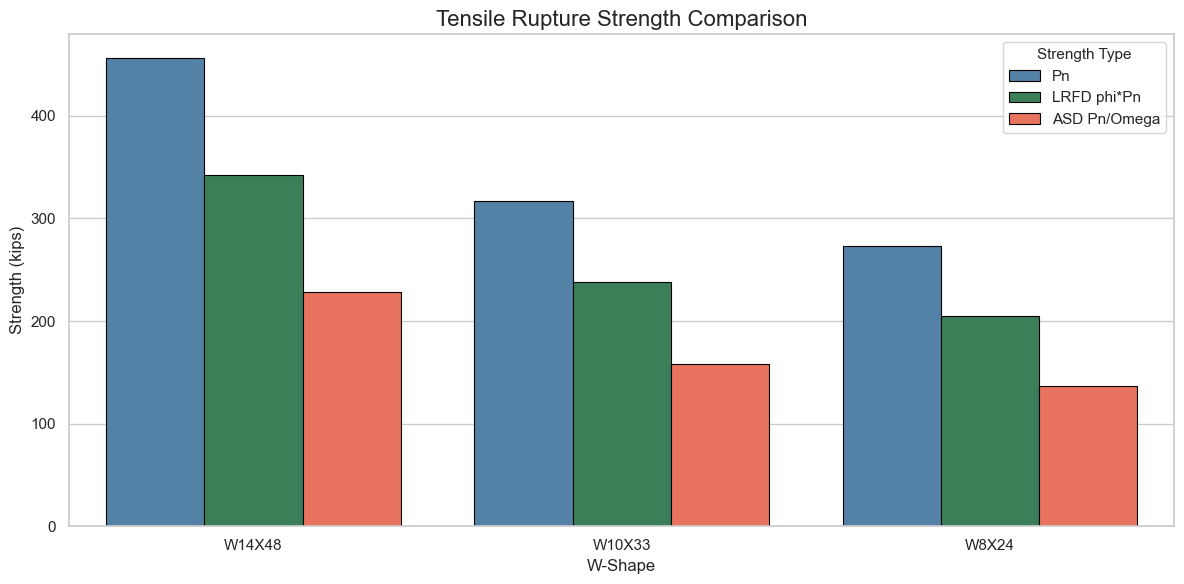

In [6]:
# This line builds a plain dictionary with the results from all three shapes.
# Seaborn can read a dictionary directly so no pandas or pyarrow conversion is needed.
plot_dict = {
    'Shape':    [result1[0]] * 3 + [result2[0]] * 3 + [result3[0]] * 3,
    'Type':     ['Pn', 'LRFD phi*Pn', 'ASD Pn/Omega'] * 3,
    'Strength': [result1[6], result1[7], result1[8],
                 result2[6], result2[7], result2[8],
                 result3[6], result3[7], result3[8]]}

# This line applies the seaborn theme and sets the bar colors before drawing.
sns.set_theme(style='whitegrid', palette=['steelblue', 'seagreen', 'tomato'])

# This line creates the figure and sets the size.
fig, ax = plt.subplots(figsize=(12, 6))

# This line plots the grouped bars using seaborn with Shape on the x axis and Strength on the y axis.
sns.barplot(data=plot_dict,
            x='Shape',
            y='Strength',
            hue='Type',
            ax=ax,
            edgecolor='black',
            linewidth=0.8)

# This line labels the x axis.
ax.set_xlabel('W-Shape', fontsize=12)

# This line labels the y axis.
ax.set_ylabel('Strength (kips)', fontsize=12)

# This line gives the plot a title.
ax.set_title('Tensile Rupture Strength Comparison', fontsize=16)

# This line adds the legend with a title.
ax.legend(title='Strength Type', fontsize=11, title_fontsize=11)

# This line displays the plot.
plt.tight_layout()
plt.show()

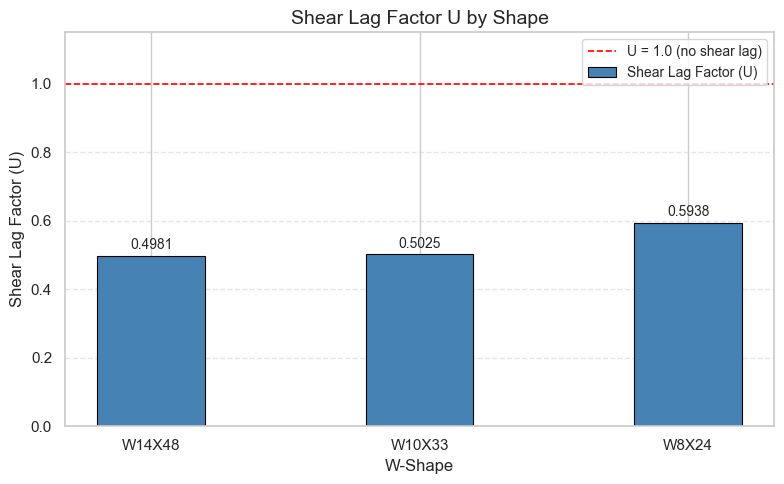

In [9]:
# This cell uses matplotlib to plot the Shear Lag Factor U for each shape.
# U=1.0 means no shear lag reduction; lower values mean more strength is lost.

# These lines pull the shape names and U values from the results.
shapes   = [result1[0], result2[0], result3[0]]
U_values = [result1[4], result2[4], result3[4]]

# This line creates the figure and axes using matplotlib directly.
fig2, ax2 = plt.subplots(figsize=(8, 5))

# This line draws the bars using matplotlib's bar() command.
# The label argument makes the bars appear in the legend.
ax2.bar(shapes, U_values, color='steelblue', edgecolor='black', linewidth=0.8, width=0.4,
        label='Shear Lag Factor (U)')

# This line adds a dashed reference line at U=1.0 to show the theoretical maximum.
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='U = 1.0 (no shear lag)')

# This line sets the y axis range so the reference line and bars are easy to compare.
ax2.set_ylim(0, 1.15)

# These lines add a value label on top of each bar.
for i, u in enumerate(U_values):
    ax2.text(i, u + 0.01, f'{u:.4f}', ha='center', va='bottom', fontsize=10)

# These lines set the axis labels, title, and legend.
ax2.set_xlabel('W-Shape', fontsize=12)
ax2.set_ylabel('Shear Lag Factor (U)', fontsize=12)
ax2.set_title('Shear Lag Factor U by Shape', fontsize=14)
ax2.legend(fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# This line displays the plot.
plt.tight_layout()
plt.show()